In [1]:
## Import required library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
# Loading datasets
cpi = pd.read_csv(r"C:\Users\sangeet.kumar\OneDrive - S&P Global\Documents\Personal\Time_series\CPI.csv")
gdp = pd.read_csv(r"C:\Users\sangeet.kumar\OneDrive - S&P Global\Documents\Personal\Time_series\GDP.csv")
unemp = pd.read_csv(r"C:\Users\sangeet.kumar\OneDrive - S&P Global\Documents\Personal\Time_series\UNEMP.csv")

In [3]:
# Displaying first few rows to understand structure
print("CPI Data:\n", cpi.head())
print("\nGDP Data:\n", gdp.head())
print("\nUnemployment Data:\n", unemp.head())

CPI Data:
   observation_date  CPIAUCSL
0       1947-01-01     21.48
1       1947-02-01     21.62
2       1947-03-01     22.00
3       1947-04-01     22.00
4       1947-05-01     21.95

GDP Data:
   observation_date      GDP
0       1947-01-01  243.164
1       1947-04-01  245.968
2       1947-07-01  249.585
3       1947-10-01  259.745
4       1948-01-01  265.742

Unemployment Data:
   observation_date  UNRATE
0       1948-01-01     3.4
1       1948-02-01     3.8
2       1948-03-01     4.0
3       1948-04-01     3.9
4       1948-05-01     3.5


In [4]:
# Rename date column to common name
cpi.rename(columns={'observation_date': 'DATE'}, inplace=True)
gdp.rename(columns={'observation_date': 'DATE'}, inplace=True)
unemp.rename(columns={'observation_date': 'DATE'}, inplace=True)

# Rename value columns
cpi.rename(columns={'CPIAUCSL': 'CPI'}, inplace=True)
unemp.rename(columns={'UNRATE': 'UNEMPLOYMENT'}, inplace=True)

In [5]:
# Convert DATE column to datetime
cpi['DATE'] = pd.to_datetime(cpi['DATE'])
gdp['DATE'] = pd.to_datetime(gdp['DATE'])
unemp['DATE'] = pd.to_datetime(unemp['DATE'])

In [6]:
# Set DATE as index
cpi.set_index('DATE', inplace=True)
gdp.set_index('DATE', inplace=True)
unemp.set_index('DATE', inplace=True)

In [7]:
# Check frequency
print(cpi.index[:5])
print(gdp.index[:5])
print(unemp.index[:5])

DatetimeIndex(['1947-01-01', '1947-02-01', '1947-03-01', '1947-04-01',
               '1947-05-01'],
              dtype='datetime64[ns]', name='DATE', freq=None)
DatetimeIndex(['1947-01-01', '1947-04-01', '1947-07-01', '1947-10-01',
               '1948-01-01'],
              dtype='datetime64[ns]', name='DATE', freq=None)
DatetimeIndex(['1948-01-01', '1948-02-01', '1948-03-01', '1948-04-01',
               '1948-05-01'],
              dtype='datetime64[ns]', name='DATE', freq=None)


In [8]:
# Convert GDP from quarterly to monthly
gdp_monthly = gdp.resample('M').ffill()

C:\Users\sangeet.kumar\AppData\Local\Temp\ipykernel_30584\269784536.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  gdp_monthly = gdp.resample('M').ffill()


In [9]:
# Convert all dates to month start format
cpi.index = cpi.index.to_period('M').to_timestamp()
gdp_monthly.index = gdp_monthly.index.to_period('M').to_timestamp()
unemp.index = unemp.index.to_period('M').to_timestamp()

In [10]:
# Find common date range
start_date = max(cpi.index.min(), gdp_monthly.index.min(), unemp.index.min())
end_date = min(cpi.index.max(), gdp_monthly.index.max(), unemp.index.max())

# Filter all datasets
cpi = cpi.loc[start_date:end_date]
gdp_monthly = gdp_monthly.loc[start_date:end_date]
unemp = unemp.loc[start_date:end_date]

In [11]:
# Merge datasets
df = cpi.join(gdp_monthly, how='inner').join(unemp, how='inner')

# View result
print(df.head())
print("Shape:", df.shape)

              CPI      GDP  UNEMPLOYMENT
DATE                                    
1948-01-01  23.68  265.742           3.4
1948-02-01  23.67  265.742           3.8
1948-03-01  23.50  265.742           4.0
1948-04-01  23.82  272.567           3.9
1948-05-01  24.01  272.567           3.5
Shape: (934, 3)


In [12]:
# Check missing values
print(df.isnull().sum())

CPI             1
GDP             0
UNEMPLOYMENT    1
dtype: int64


In [13]:
# Remove rows with missing values
df = df.dropna()

# Check again
print(df.isnull().sum())
print("New Shape:", df.shape)

CPI             0
GDP             0
UNEMPLOYMENT    0
dtype: int64
New Shape: (933, 3)


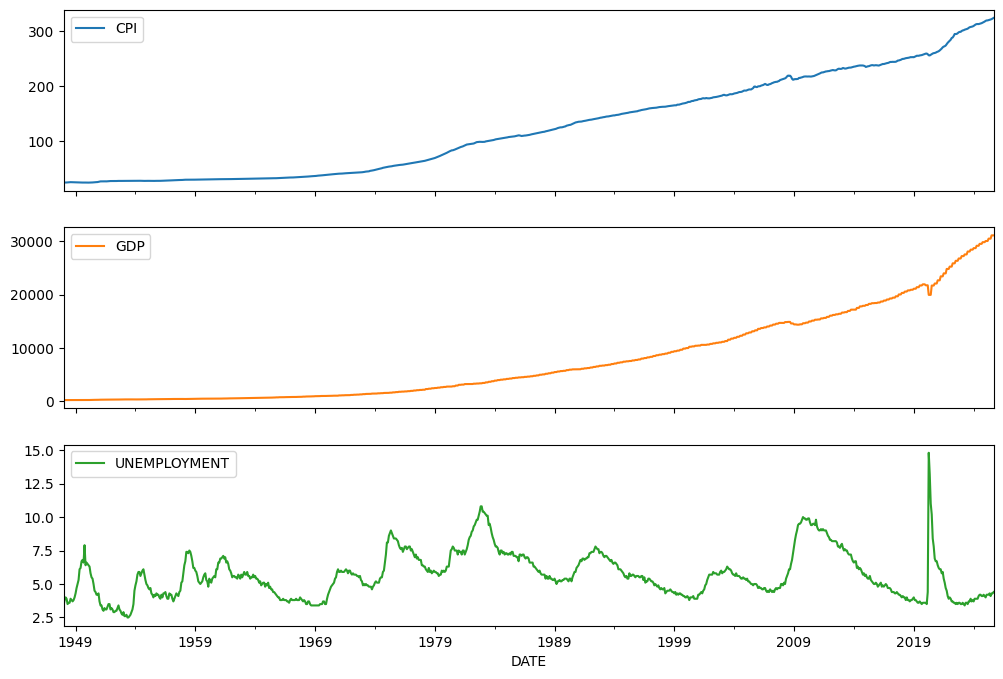

In [14]:
import matplotlib.pyplot as plt

# Plot variables
df[['CPI', 'GDP', 'UNEMPLOYMENT']].plot(subplots=True, figsize=(12,8))

plt.show()

## Interpretation

### CPI (Inflation)
#### What we see:

Strong upward trend

No major drops

Faster increase in recent years

CPI shows a strong long-term upward trend, indicating persistent inflation with acceleration in recent years.

### GDP
#### What we see:
Overall growth trend

Some dips (small but visible)

Sharp drop around recent years

Economy grows over time but faces periodic shocks

GDP exhibits long-term growth with noticeable downturns during economic shocks such as financial crises.

### Unemployment
#### What we see:
Fluctuates (not trending like CPI/GDP)

Clear spikes:

>Around ~1980

>Around ~2008

>BIG spike around ~2020

Unemployment spikes during crises

Unemployment shows cyclical behavior with sharp spikes during economic downturns, particularly during the 2008 financial crisis and the COVID-19 period.

### The dataset shows expected macroeconomic relationships, where GDP growth corresponds with lower unemployment, while economic downturns lead to unemployment spikes.

In [15]:
# --- LAG FEATURES (past values) ---

# CPI last month
df['lag_1'] = df['CPI'].shift(1)

# CPI 3 months ago
df['lag_3'] = df['CPI'].shift(3)

# CPI 6 months ago
df['lag_6'] = df['CPI'].shift(6)

# CPI 12 months ago (very important for yearly patterns)
df['lag_12'] = df['CPI'].shift(12)

In [16]:
# --- ROLLING FEATURES (moving averages) ---

# 3-month moving average
df['rolling_mean_3'] = df['CPI'].rolling(window=3).mean()

# 6-month moving average
df['rolling_mean_6'] = df['CPI'].rolling(window=6).mean()

In [17]:
# --- INFLATION FEATURES ---

# Month-over-Month inflation
df['inflation_mom'] = df['CPI'].pct_change(1)

# Year-over-Year inflation
df['inflation_yoy'] = df['CPI'].pct_change(12)

In [18]:
# Drop rows created due to lag/rolling features
df = df.dropna()

print(df.head())
print("New Shape:", df.shape)

              CPI      GDP  UNEMPLOYMENT  lag_1  lag_3  lag_6  lag_12  \
DATE                                                                    
1949-01-01  24.01  275.034           4.3  24.05  24.31  24.40   23.68   
1949-02-01  23.91  275.034           4.7  24.01  24.16  24.43   23.67   
1949-03-01  23.91  275.034           5.0  23.91  24.05  24.36   23.50   
1949-04-01  23.92  271.351           5.3  23.91  24.01  24.31   23.82   
1949-05-01  23.91  271.351           6.1  23.92  23.91  24.16   24.01   

            rolling_mean_3  rolling_mean_6  inflation_mom  inflation_yoy  
DATE                                                                      
1949-01-01       24.073333       24.220000      -0.001663       0.013936  
1949-02-01       23.990000       24.133333      -0.004165       0.010139  
1949-03-01       23.943333       24.058333       0.000000       0.017447  
1949-04-01       23.913333       23.993333       0.000418       0.004198  
1949-05-01       23.913333       23.95

In [19]:
# Define target (what we want to predict)
y = df['CPI']

# Define features (everything except CPI)
X = df.drop(columns=['CPI'])

In [20]:
# Split based on time (80% train, 20% test)
train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [21]:
# Training Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
#Predict
y_pred = model.predict(X_test)

In [23]:
#Evaluate Model
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.18938248643053465
RMSE: 0.269443188387024


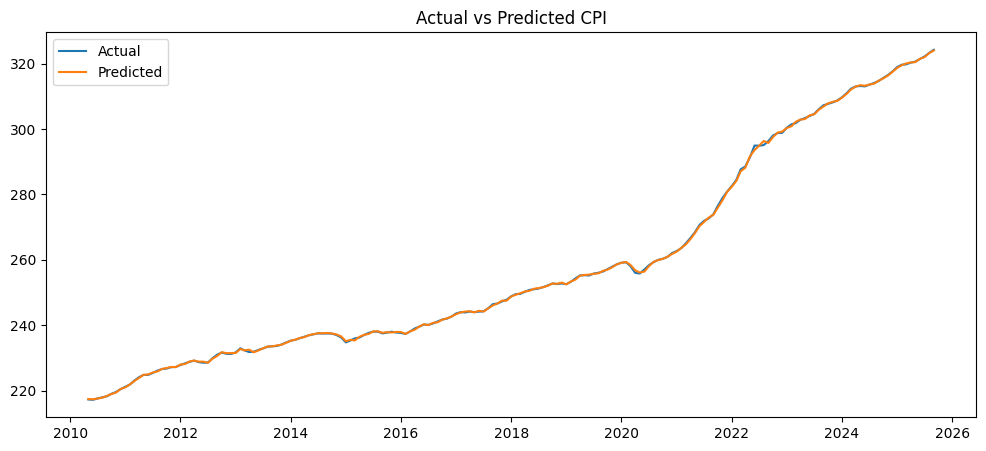

In [24]:
#Plot Results
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='Predicted')

plt.legend()
plt.title("Actual vs Predicted CPI")
plt.show()

### What we see in the above graph:
Predicted line almost overlaps actual line

Trend captured perfectly

Even small dips (like ~2020) are captured

Learned trend

Learned seasonality (implicitly via lags)

Learned relationships

The strong performance is driven by autoregressive features (lag variables), which provide the model with past CPI values, making prediction easier.

In [25]:
# Check Stationarity (ADF Test)
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['CPI'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 2.626045671775854
p-value: 0.9990795195567231


### Interpretation

p-value = 0.999 (very high)

#### Rule:
p < 0.05 → Stationary

p > 0.05 → Not Stationary
### Conclusion

CPI series is: NOT stationary

#### Why This Happens (Intuition)

From our graph:

CPI is continuously increasing

Has strong trend

#### Stationarity means:

Data should fluctuate around a constant mean

#### CPI does NOT → so fails test

#### Explanation

The ADF test showed a high p-value (~0.99), indicating the CPI series is non-stationary due to a strong upward trend.

In [26]:
# Apply Differencing
# To Removes trend
# To Makes data stable
# Now suitable for ARIMA


# First-order differencing
df['CPI_diff'] = df['CPI'].diff()

# Drop NaN created due to differencing
df = df.dropna()

print(df[['CPI', 'CPI_diff']].head())

              CPI  CPI_diff
DATE                       
1949-02-01  23.91     -0.10
1949-03-01  23.91      0.00
1949-04-01  23.92      0.01
1949-05-01  23.91     -0.01
1949-06-01  23.92      0.01


In [27]:
# Check Stationarity Again
result = adfuller(df['CPI_diff'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.7690767271132275
p-value: 0.003240028342735291


### Interpretation

p-value = 0.0034 (< 0.05)

#### Conclusion:

our data is now STATIONARY

#### Before:

CPI had trend

Not usable for ARIMA

#### After differencing:

Trend removed
Stable mean 

#### Ready for modeling

The original CPI series was non-stationary (p > 0.05), so I applied first-order differencing. The transformed series passed the ADF test (p < 0.05), making it suitable for ARIMA modeling.

In [28]:
# Import ARIMA
from statsmodels.tsa.arima.model import ARIMA

In [29]:
# Build Model

# We start with simple parameters: (p=1, d=1, q=1)
model = ARIMA(df['CPI'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    CPI   No. Observations:                  920
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -467.215
Date:                Sat, 21 Mar 2026   AIC                            940.431
Time:                        18:34:10   BIC                            954.901
Sample:                    02-01-1949   HQIC                           945.953
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7915      0.013     58.886      0.000       0.765       0.818
ma.L1         -0.1545      0.022     -7.141      0.000      -0.197      -0.112
sigma2         0.1617      0.003     48.791      0.0

### Model Summary (Key Insights)

"""
Let’s simplify our output:

AR (Auto-Regressive) Term
ar.L1 = 0.79

Strong dependence on past values
CPI is highly persistent

MA (Moving Average) Term
ma.L1 = -0.15

Adjusts for short-term shocks

Sigma² (Variance)
sigma² ≈ 0.16

Low variance → stable model 
#### Diagnostic Insights

 Ljung-Box Test

 Prob(Q) = 0.88

#### Residuals are uncorrelated
#### Model captured time structure well
"""

In [30]:
# Make Predictions
# Predict on last 20% data
start = int(len(df) * 0.8)
end = len(df) - 1

pred = model_fit.predict(start=start, end=end, typ='levels')

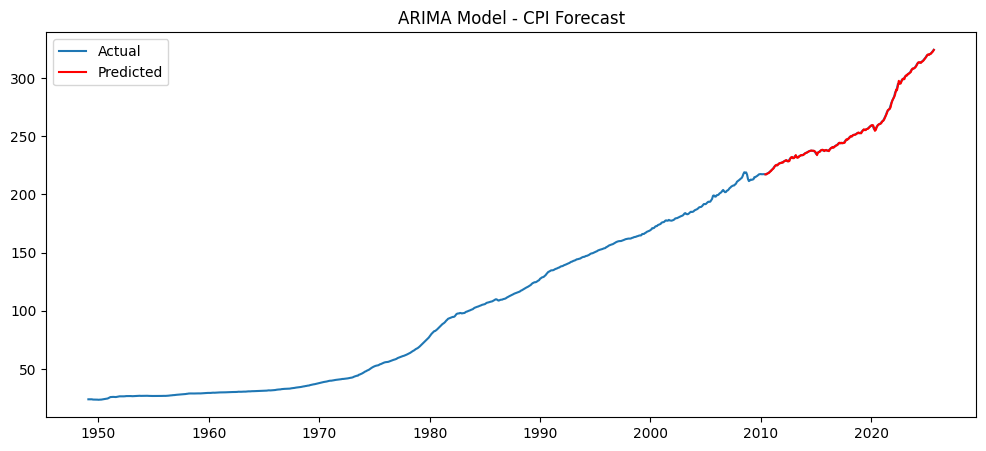

In [31]:
#Plot Results
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df['CPI'], label='Actual')
plt.plot(pred, label='Predicted', color='red')

plt.legend()
plt.title("ARIMA Model - CPI Forecast")
plt.show()

### What we see in the above graph:
Red line (predicted) follows trend

Smooth continuation of CPI

Captures upward trend well

## Interpretation

### ARIMA:

Captures trend direction well

But less reactive to small fluctuations


### While Linear Regression achieved lower error due to lag features, ARIMA provides a more robust time-series framework by modeling temporal dependencies directly without explicit feature engineering.

### Insights from Analysis
1. Inflation Insight (CPI):

 Based on your graph:

Inflation shows a strong long-term upward trend, with accelerated growth in recent years, indicating persistent price increases in the economy.

2. GDP Insight :
GDP demonstrates consistent long-term growth with periodic downturns, reflecting economic cycles and shocks such as financial crises.
3. Unemployment Insight:
Unemployment exhibits cyclical behavior, with sharp spikes during economic downturns, particularly during major crises such as 2008 and COVID-19.
4. Relationship Insight:
There is an inverse relationship between GDP and unemployment, where economic growth corresponds to lower unemployment levels, and downturns lead to higher unemployment.
5. Model Insight:
Time-series models such as ARIMA effectively capture long-term trends in CPI, while machine learning models using lag features provide highly accurate short-term predictions.

### Preparing Data for Power BI Dashboard

In [32]:
# Create a clean dataset for Power BI
final_df = df.copy()

# Reset index so DATE becomes a column
final_df = final_df.reset_index()

# Save to CSV
final_df.to_csv("final_macro_data.csv", index=False)

print("File saved successfully!")

File saved successfully!


In [33]:
import os
print(os.getcwd())

C:\Users\sangeet.kumar
